### 1. Imports & Setup

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Configure visualization style
sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

# Load the dataset
df = pd.read_csv('data/customer_info.csv')

# Create a working copy to preserve original data
data = df.copy()

Libraries imported successfully.


### 2. Data Preparation

In [27]:
# Set customer_id as the index
if 'customer_id' in data.columns:
    data.set_index('customer_id', inplace=True)

# Check and remove duplicate rows
initial_count = len(data)
data.drop_duplicates(inplace=True)
dropped_count = initial_count - len(data)

print(f"Original rows: {initial_count}")
print(f"Duplicates dropped: {dropped_count}")
print(f"Current rows: {len(data)}")

# Display the first few rows to verify
display(data.head())

Original rows: 16978
Duplicates dropped: 0
Current rows: 16978


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,Louis Huffman,male,08/22/1948 05:06 AM,0.0,2.0,2.0,3.0,6238.0,818.0,18.0,...,1039.0,361.0,457.0,1520.0,210.0,0.623414,2000.0,917650.0,38.683897,-9.172942
6538,Msc. Noel Ward,male,02/12/1967 07:51 PM,2.0,1.0,3.0,3.0,4188.0,1048.0,14.0,...,1913.0,562.0,67.0,957.0,92.0,0.555637,2017.0,906928.0,38.790490,-9.115064
14274,Bsc. Scott Giordano,male,04/10/1986 05:10 PM,0.0,0.0,1.0,1.0,25269.0,4047.0,12.0,...,303.0,724.0,442.0,1213.0,85.0,0.259248,2014.0,958107.0,38.775609,-9.112610
7796,William Lacy,male,01/03/1999 01:47 AM,0.0,1.0,1.0,3.0,8292.0,1524.0,15.0,...,1877.0,560.0,1028.0,1005.0,169.0,0.419730,2024.0,967864.0,38.736641,-9.158548
4521,Bsc. Nathan Minor,male,10/21/1957 07:34 AM,3.0,1.0,2.0,3.0,43692.0,3718.0,10.0,...,3093.0,1635.0,868.0,745.0,345.0,0.428821,2004.0,971603.0,38.726597,-9.109803


### 3. Data Cleaning

In [28]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# Imputation Strategy
# 1. Numerical: Fill with Median
num_cols = data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

# 2. Categorical: Fill with Mode (Most frequent value)
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    if not data[col].mode().empty:
        data[col] = data[col].fillna(data[col].mode()[0])

print("\nMissing values after imputation:\n", data.isnull().sum().sum())

Missing values per column:
 customer_birthdate                 68
kids_home                          85
teens_home                         68
number_complaints                  51
distinct_stores_visited           170
typical_hour                       68
lifetime_spend_vegetables          85
lifetime_spend_alcohol_drinks     170
lifetime_spend_fish               170
loyalty_card_number              3143
dtype: int64

Missing values after imputation:
 0


### 4. Detect and Remove Outliers

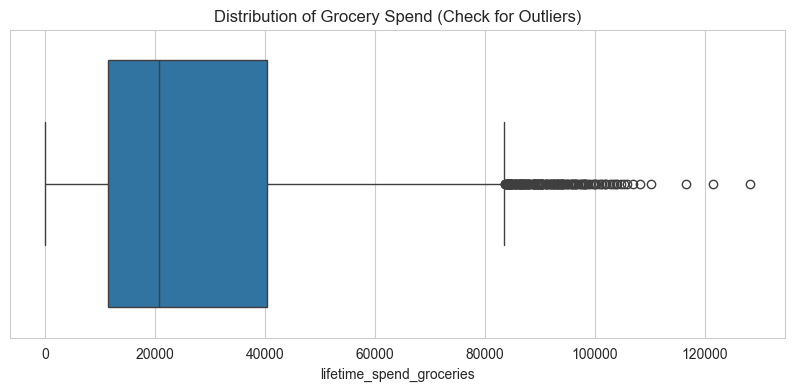

In [29]:
def remove_outliers_iqr(df, column_name):
    """Removes outliers based on the IQR method."""
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    print(f"Removed {len(df) - len(filtered_df)} outliers from {column_name}")
    return filtered_df

# Apply to a column likely to have noise, e.g., 'distinct_stores_visited' or 'number_complaints'
# You can uncomment the line below to apply it to spending if desired
# data = remove_outliers_iqr(data, 'lifetime_spend_groceries')

# Visualizing outliers before/after (Optional)
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['lifetime_spend_groceries'])
plt.title('Distribution of Grocery Spend (Check for Outliers)')
plt.show()

### 5. Featura Engineering

In [30]:
# 1. Age Calculation
# Convert birthdate to datetime and extract year
data['customer_birthdate'] = pd.to_datetime(data['customer_birthdate'])
current_year = 2025  # Assuming the report year is 2025
data['Age'] = current_year - data['customer_birthdate'].dt.year

# 2. Customer Tenure
data['Customer_Tenure'] = current_year - data['year_first_transaction']

# 3. Total Lifetime Spend (Summing all category spends)
spend_columns = [col for col in data.columns if 'lifetime_spend_' in col]
data['Total_Lifetime_Spend'] = data[spend_columns].sum(axis=1)

# 4. Total Minors (Kids + Teens)
data['Total_Minors'] = data['kids_home'] + data['teens_home']

# 5. Binary Encoding for Gender
# Group 13 created 'Is_Female' dummy variable
data['Is_Female'] = data['customer_gender'].apply(lambda x: 1 if str(x).lower().strip() in ['female', 'f'] else 0)

# Drop columns that are no longer needed
cols_to_drop = ['customer_name', 'customer_gender', 'customer_birthdate', 
                'year_first_transaction', 'loyalty_card_number', 'latitude', 'longitude']
data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

display(data[['Age', 'Customer_Tenure', 'Total_Lifetime_Spend', 'Is_Female']].head())

,Age,Customer_Tenure,Total_Lifetime_Spend,Is_Female
customer_id,,,,
11259,77,25.0,17056.0,0
6538,58,8.0,18675.0,0
14274,39,11.0,40362.0,0
7796,26,1.0,21337.0,0
4521,68,21.0,71789.0,0


### 6. Correlations

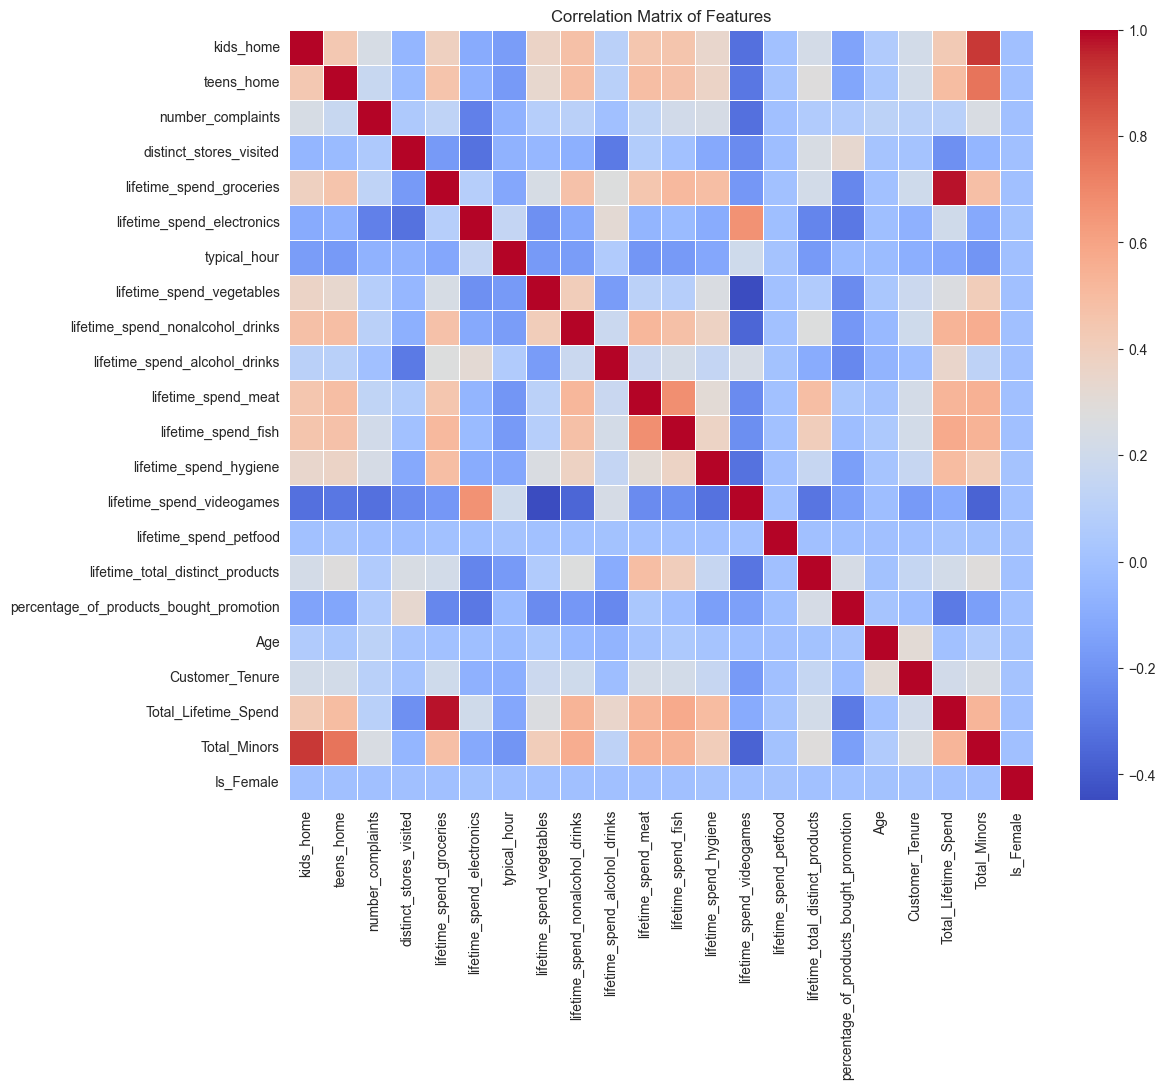

Correlation with Total Spend:

Total_Lifetime_Spend                1.000000
lifetime_spend_groceries            0.980362
lifetime_spend_fish                 0.573846
lifetime_spend_nonalcohol_drinks    0.534039
lifetime_spend_meat                 0.527541
Name: Total_Lifetime_Spend, dtype: float64


In [31]:
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# Optional: Check correlation with Total Spend to see drivers
print("Correlation with Total Spend:\n")
print(correlation_matrix['Total_Lifetime_Spend'].sort_values(ascending=False).head(5))

### 7. Scaling

In [32]:
# Initialize RobustScaler
scaler = RobustScaler()

# Fit and transform the data
data_scaled_array = scaler.fit_transform(data)

# Convert back to DataFrame for readability and further analysis
data_scaled = pd.DataFrame(data_scaled_array, columns=data.columns, index=data.index)

print("Scaling complete. Data is ready for clustering (Group 5).")
display(data_scaled.head())

Scaling complete. Data is ready for clustering (Group 5).


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,Age,Customer_Tenure,Total_Lifetime_Spend,Total_Minors,Is_Female
customer_id,,,,,,,,,,,,,,,,,,,,,
11259,-0.333333,0.5,0.5,1.0,-0.503204,-0.673392,0.375,-0.336297,-0.307011,-0.115880,...,-0.414562,-0.323171,0.943431,0.410072,0.695476,0.741935,1.875,-0.550353,0.000000,-1.0
6538,0.333333,0.0,1.0,1.0,-0.574125,-0.573598,-0.125,-0.140317,-0.265683,0.725322,...,-0.115899,-1.002613,-0.083942,-0.438849,0.477321,0.129032,-0.250,-0.507652,0.333333,-1.0
14274,-0.333333,-0.5,0.0,-1.0,0.155177,0.727628,-0.375,0.959412,0.211365,-0.811874,...,0.124814,-0.349303,0.383212,-0.489209,-0.476672,-0.483871,0.125,0.064342,-0.666667,-1.0
7796,-0.333333,0.0,0.0,1.0,-0.432146,-0.367068,0.000,-0.054890,-0.796458,-0.457797,...,-0.118871,0.671603,0.003650,0.115108,0.039874,-0.903226,-1.125,-0.437442,-0.333333,-1.0
4521,0.666667,0.0,0.5,1.0,0.792524,0.584879,-0.625,1.408968,0.599262,0.165951,...,1.478455,0.392857,-0.470803,1.381295,0.069137,0.451613,1.375,0.893228,0.666667,-1.0


### 8. Save Output

In [33]:
data_scaled.to_csv('data/processed_customer_data.csv')